In [56]:
!pip install optuna
!pip install shap
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, classification_report

# Imbalance
from imblearn.over_sampling import SMOTE

# Model
from xgboost import XGBClassifier

# Hyperparameter tuning
import optuna  # Now this will work after installation

# Explainability
import shap
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [57]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [58]:
print(df.shape)
print(df["Class"].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


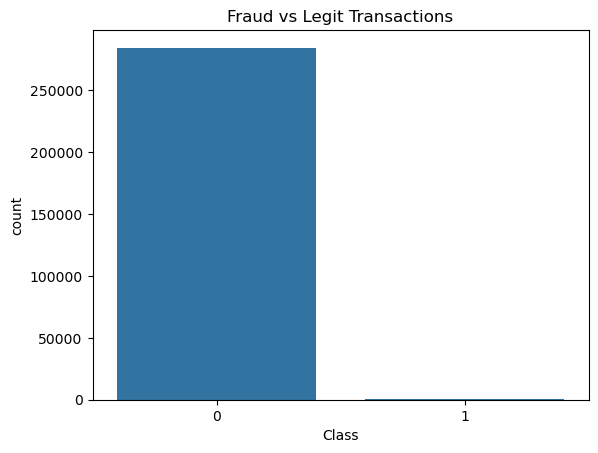

In [59]:
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Legit Transactions")
plt.show()

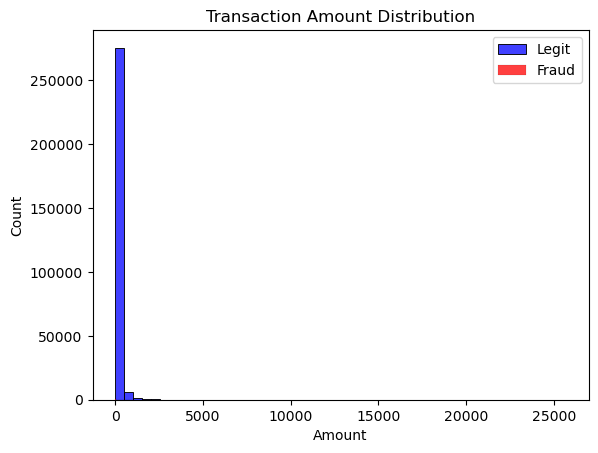

In [60]:
sns.histplot(df[df["Class"]==0]["Amount"], bins=50, color="blue", label="Legit")
sns.histplot(df[df["Class"]==1]["Amount"], bins=50, color="red", label="Fraud")
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

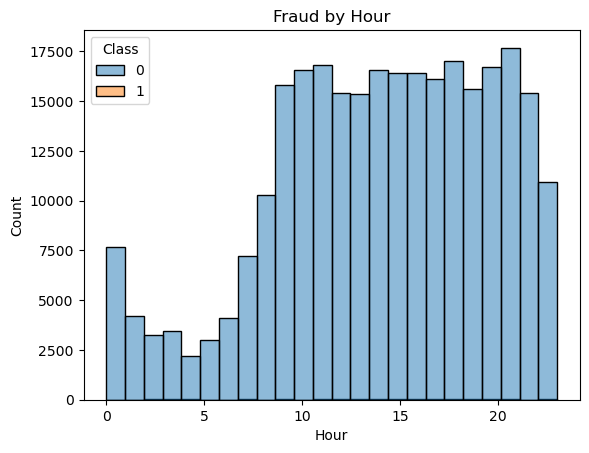

In [61]:
df["Hour"] = (df["Time"] // 3600) % 24
# ✅ NEW Feature 1: Night transactions
df["is_night"] = df["Hour"].apply(lambda x: 1 if x < 6 else 0)

# ✅ NEW Feature 2: Log transform of amount
df["amount_log"] = np.log1p(df["Amount"])

sns.histplot(data=df, x="Hour", hue="Class", bins=24)
plt.title("Fraud by Hour")
plt.show()

In [62]:
df = df.sort_values(by=["Time"])

df["tx_count_1hr"] = df.groupby("Class")["Time"].transform(
    lambda x: x.rolling(100).count()
)

In [63]:
df["Amount_zscore"] = (df["Amount"] - df["Amount"].mean()) / df["Amount"].std()

In [64]:
df["time_diff"] = df["Time"].diff().fillna(0)

In [65]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [66]:
# Import necessary libraries if not already imported
from sklearn.impute import SimpleImputer
import pandas as pd
from imblearn.over_sampling import SMOTE

# Create an imputer to fill NaN values
imputer = SimpleImputer(strategy='mean')  # You can choose 'mean', 'median', 'most_frequent', or 'constant'

# Apply the imputer to fill NaN values in X_train
X_train_imputed = imputer.fit_transform(X_train)

# Now apply SMOTE on the imputed data
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imputed, y_train)

print("Before:", y_train.value_counts())
print("After:", pd.Series(y_train_res).value_counts())

Before: Class
0    227451
1       394
Name: count, dtype: int64
After: Class
0    227451
1    113725
Name: count, dtype: int64


In [67]:
scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])) * 0.7

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 404.1007614213198


In [68]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        
    }

    model = XGBClassifier(**params, eval_metric="logloss")
    model.fit(X_train_res, y_train_res)

    probs = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, probs)

    # Target: high precision
    mask = precision >= 0.95
    if np.sum(mask) == 0:
        return 0

    return max(recall[mask])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

best_params = study.best_params
print(best_params)

[I 2026-03-28 15:59:39,903] A new study created in memory with name: no-name-22fa877f-3c33-4771-9f63-25849109098e
[I 2026-03-28 15:59:44,432] Trial 0 finished with value: 0.8061224489795918 and parameters: {'n_estimators': 363, 'max_depth': 6, 'learning_rate': 0.28859781814954716, 'subsample': 0.8176847580789763, 'colsample_bytree': 0.6836421803408693}. Best is trial 0 with value: 0.8061224489795918.
[I 2026-03-28 15:59:48,241] Trial 1 finished with value: 0.8061224489795918 and parameters: {'n_estimators': 371, 'max_depth': 4, 'learning_rate': 0.11574620289344582, 'subsample': 0.8899018820066745, 'colsample_bytree': 0.6583364647720908}. Best is trial 0 with value: 0.8061224489795918.
[I 2026-03-28 15:59:51,840] Trial 2 finished with value: 0.8469387755102041 and parameters: {'n_estimators': 203, 'max_depth': 7, 'learning_rate': 0.1902388989663707, 'subsample': 0.9459124385678528, 'colsample_bytree': 0.9578186168309063}. Best is trial 2 with value: 0.8469387755102041.
[I 2026-03-28 15:

{'n_estimators': 203, 'max_depth': 7, 'learning_rate': 0.1902388989663707, 'subsample': 0.9459124385678528, 'colsample_bytree': 0.9578186168309063}


In [69]:
# Remove scale_pos_weight if present
best_params.pop("scale_pos_weight", None)

model = XGBClassifier(**best_params, eval_metric="logloss")
model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9578186168309063, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1902388989663707,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=203, n_jobs=None,
              num_parallel_tree=None, ...)

In [70]:
probs = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Find threshold where precision >= 95%
target_precision = 0.93

best_recall = 0
best_threshold = 0.5

for p, r, t in zip(precision, recall, thresholds):
    if p >= target_precision and r > best_recall:
        best_recall = r
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best Recall:", best_recall)

Best Threshold: 0.923246
Best Recall: 0.8469387755102041


In [71]:
y_pred = (probs >= best_threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.85      0.89        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [72]:
y_pred = (probs >= best_threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.85      0.89        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [73]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

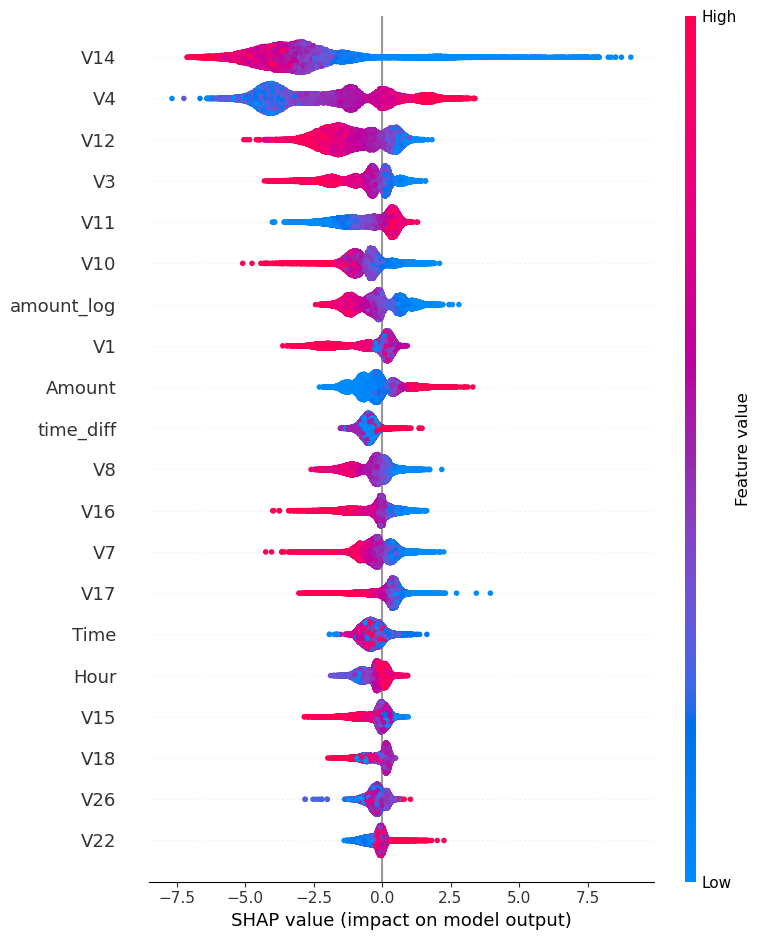

In [74]:
shap.summary_plot(shap_values, X_test)

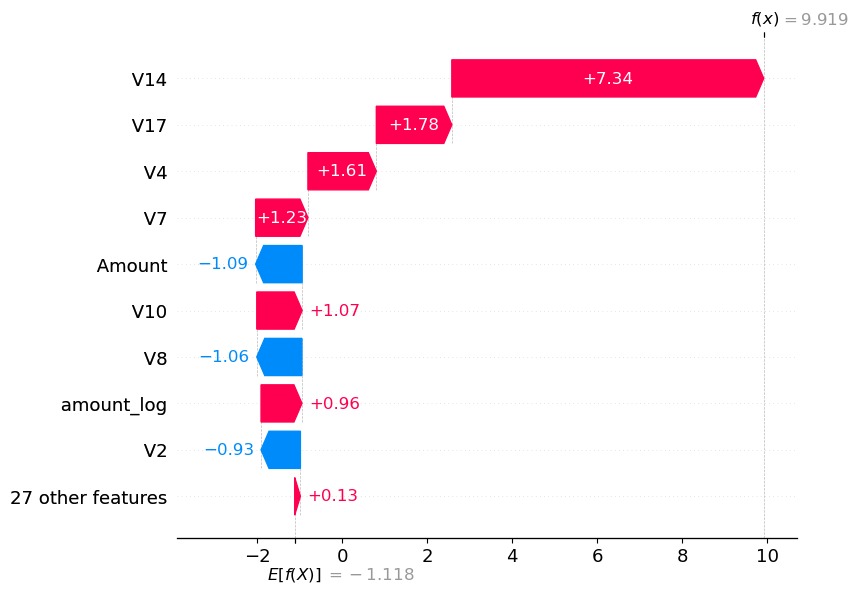

In [75]:
# Pick a fraud case
fraud_index = np.where(y_test == 1)[0][0]

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[fraud_index],
    X_test.iloc[fraud_index]
)

In [76]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(best_threshold, "threshold.pkl")

['threshold.pkl']